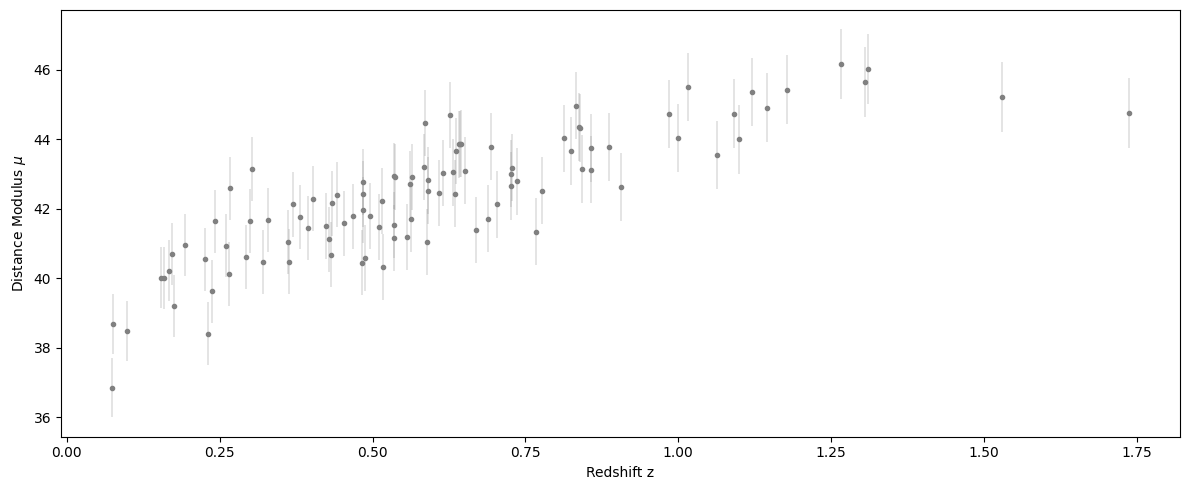

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from astroML.datasets import generate_mu_z
def Load_Dataset(nSamples):
    z_sample, mu_sample, dmu = generate_mu_z(nSamples, random_state=1234)
    return z_sample, mu_sample, dmu

zSample, muSample, dMu = Load_Dataset(100)
plt.figure(figsize=(12,5), tight_layout=True)
plt.errorbar(zSample, muSample, dMu, marker='o', c='gray', lw=0, markersize=3, elinewidth=0.3)#,label='data')
plt.xlabel("Redshift z")
_ = plt.ylabel(r"Distance Modulus $\mu$")

First let's fit our supernova synthetic data from last time using GPR.

- The key ingredient in getting a good GPR fit is the choice of the kernel and its parameters.
- Check out what's available in the kernels submodule of sklearn.gaussian_process
- Hint. Radial-basis function kernel (aka squared-exponential kernel) is a standard choice in the GPR world.
- Plot the expectation value of the fit as well as the resulting 1-$\sigma$ and 2-$\sigma$ contours.

Interpret the results.

C:\Users\alfac\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\gaussian_process\kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


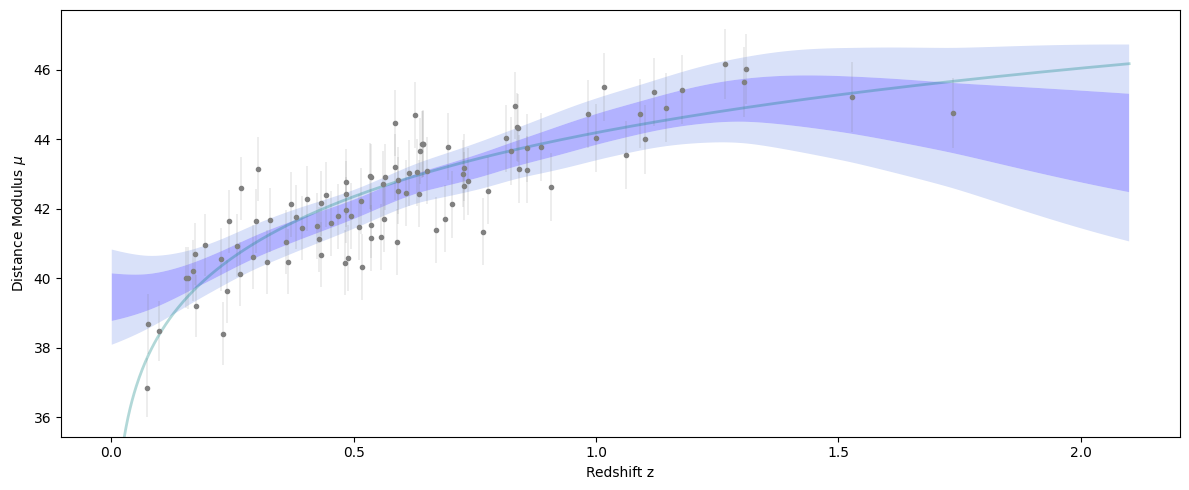

In [87]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import WhiteKernel, ExpSineSquared, RBF, ConstantKernel, DotProduct, Matern, RationalQuadratic
from astropy.cosmology import FlatLambdaCDM
plt.figure(tight_layout=True, figsize=(12,5))
cosmo = FlatLambdaCDM(Om0=0.3, H0=100*0.673, Tcmb0=2.7525)

zSample, muSample, dMu = Load_Dataset(100)
plt.errorbar(zSample, muSample, dMu, markersize=3, marker='o', elinewidth=0.2, color='gray', lw=0) #,label='data')
plt.ylim(plt.gca().get_ylim())
plt.xlabel("Redshift z")
plt.ylabel(r"Distance Modulus $\mu$")

zGrid = np.linspace(1e-3, 2.1, 1000)
import astropy.units as u
plt.plot(zGrid, 5*np.log10(cosmo.luminosity_distance(zGrid).to(u.pc).value)-5, c='teal', lw=2, alpha=0.3)

### dKernel = ConstantKernel(1, (1e-3, 1e3)) * RBF(length_scale=1, length_scale_bounds=(1e-2, 1e2)) 
dKernel = Matern(length_scale=1, nu=1.1) + WhiteKernel(5)
GPR = GaussianProcessRegressor(kernel=dKernel, alpha=dMu**2, normalize_y=True, n_restarts_optimizer=1) ### He can optimize itself, so... let's start with that!
GPR.fit(np.reshape(zSample,(-1,1)), y=muSample)
muGrid, muRms = GPR.predict(zGrid.reshape(-1,1), return_std=True)

_ = plt.fill_between(x=zGrid, y1=muGrid-muRms,   y2=muGrid+muRms,   where=[True for _ in muRms], facecolor='blue',      alpha=0.3)
_ = plt.fill_between(x=zGrid, y1=muGrid+muRms,   y2=muGrid+2*muRms, where=[True for _ in muRms], facecolor='royalblue', alpha=0.2)
_ = plt.fill_between(x=zGrid, y1=muGrid-2*muRms, y2=muGrid-muRms,   where=[True for _ in muRms], facecolor='royalblue', alpha=0.2)
#_ = plt.fill_between(x=zGrid, y1=muGrid+2*muRms, y2=2*muGrid+3*muRms, where=[True for _ in muRms], facecolor='royalblue', alpha=0.1)
#_ = plt.fill_between(x=zGrid, y1=muGrid-3*muRms, y2=muGrid-2*muRms,   where=[True for _ in muRms], facecolor='royalblue', alpha=0.1)

The GPR with a "standard" and "naive" approach is extremely good at fitting the dataset, in particular in the high-z range where my polynomials and other regressors were underperforming. Moreover, the previous regression algorithms were _extremely_ bad at fitting the high-z regime: the scarcity of datapoints was not helping, and overfitting the data would cause my predictions to basically "sink" down to much lower $\mu$'s at high $z$, which was very unreasonable!

On the other hand, in this case I don't have a point-value prediction, but a wide area which could "host" my next Type-1A SNe events. This is WAY more powerful than the previous case, where I would only get a point estimate.

Another consideration that I could make is the following: at low redshift, the prediction does NOT match the parametric model that we have at our disposal ($\Lambda$CDM). This could be explained by the fact that at low-z the comoving volume which could enclosing these events is much smaller, and Type-1A SNe's are somewhat rare!

In [3]:
print('{0:.4e} vs. {1:.4e}'.format(cosmo.differential_comoving_volume(0.1), cosmo.differential_comoving_volume(2)))
print('{0:.4e} vs. {1:.4e}'.format(cosmo.comoving_volume(0.1), cosmo.comoving_volume(2)))

8.0481e+08 Mpc3 / sr vs. 4.3553e+10 Mpc3 / sr
3.4536e+08 Mpc3 vs. 6.5471e+11 Mpc3


- Assuming a flat Universe, we have a parametric non-linear model for $\mu$ that depends on two parameters, the Hubble constant $H_{0}$ and the matter content of the Universe $\Omega_{m}$.

- It's a very non-linear model. Fit it to the data (however you want to do it, are you frequentist or Bayesian after all?).

- What are the measured value of $H_{0}$ and $\Omega_{m}$? Are they correlated?

I would like to use #njit, therefore I am preparing to avoid astropy at all costs.

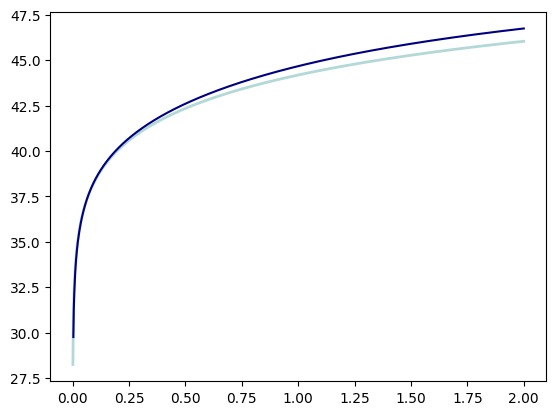

In [4]:
from astropy.constants import c

c_kms = c.to(u.km/u.s).value
from numba import njit, float64
@njit(float64(float64, float64, float64))
def Model(z, H0, Om0):
    Oe0 = 1-Om0
    zVals = np.linspace(1e-3, z, 1000)
    integrand = np.sqrt(Om0*(1+zVals**3)+Oe0)**(-1)
    integral = np.trapz(x=zVals, y=integrand)
    arg = c_kms/H0 /10 *1e6 * (1+z) * integral
    return 5 * np.log10(arg)
    
cosmo = FlatLambdaCDM(Om0=0.30, H0=100*0.673, Tcmb0=2.7525)

zGrid = np.linspace(1e-3, 2, 1000)
plt.plot(zGrid, 5*np.log10(cosmo.luminosity_distance(zGrid).to(u.pc).value)-5, c='teal', lw=2, alpha=0.3)
plt.plot(zGrid, [ Model(z, cosmo.H0.value, cosmo.Om0) for z in zGrid], c='navy')

This doesn't look great at high redshift. It is very likely that I am missing some K-corrections in the model, but it will do for z smaller than 2.

In [5]:
zGrid = np.linspace(1e-6, 2, 1000)

from astropy.constants import c
c_kms = c.to(u.km/u.s).value

@njit(float64(float64, float64[:]))
def Model(z, params):
    Om0 = params[0]
    H0  = params[1]
    Oe0 = 1-Om0
    zVals = np.linspace(0, z, 10000)
    integrand = np.sqrt(Om0*(1+zVals**3)+Oe0)**(-1)
    integral  = np.trapz(x=zVals, y=integrand)
    result = 5* np.log10(c_kms/H0*1e5 * (1+z) * integral) #1e5 = x Mpc / 10 pc
    if np.isnan(result) == True: return -np.inf
    return result

@njit(float64(float64[:]))
def LogLikelihood(params):
    Om0, H0 = params    
    if Om0 < 0 : ### I really don't want negative masses
        return -np.inf
    logL = 0
    for z, mu, err in zip(zSample, muSample, dMu):
        logL = logL - ( mu - Model(z, params) )**2 / 2*np.pi/err**2 - 0.5*np.log10(2*np.pi*err**2)
    if np.isnan(logL) == True: return -np.inf
    return logL

import scipy.stats
### Squeezing the domain around what I "know" to be the "correct" value. Sorry!
uGrid = np.linspace(0, 1, 10000)
ppf_Om0 = np.array( scipy.stats.uniform(0.1, 0.5).ppf(uGrid) )
ppf_H0  = np.array( scipy.stats.uniform(65 , 85 ).ppf(uGrid) ) 

@njit(float64[:](float64[:]))
def uPrior(params):
    Om0 = ppf_Om0[ ( np.abs(uGrid - params[0]) ).argmin() ]
    H0  = ppf_H0 [ ( np.abs(uGrid - params[1]) ).argmin() ]
    return np.array([Om0, H0]) 

import dynesty
sampler = dynesty.NestedSampler(LogLikelihood, uPrior, ndim=2, nlive=1000)
sampler.run_nested(print_progress=True, dlogz=0.01)
sresults = sampler.results

7688it [04:05, 31.26it/s, +1000 | bound: 6 | nc: 1 | ncall: 44468 | eff(%): 19.987 | loglstar:   -inf < -186.488 <    inf | logz: -189.561 +/-  0.048 | dlogz:  0.000 >  0.010]


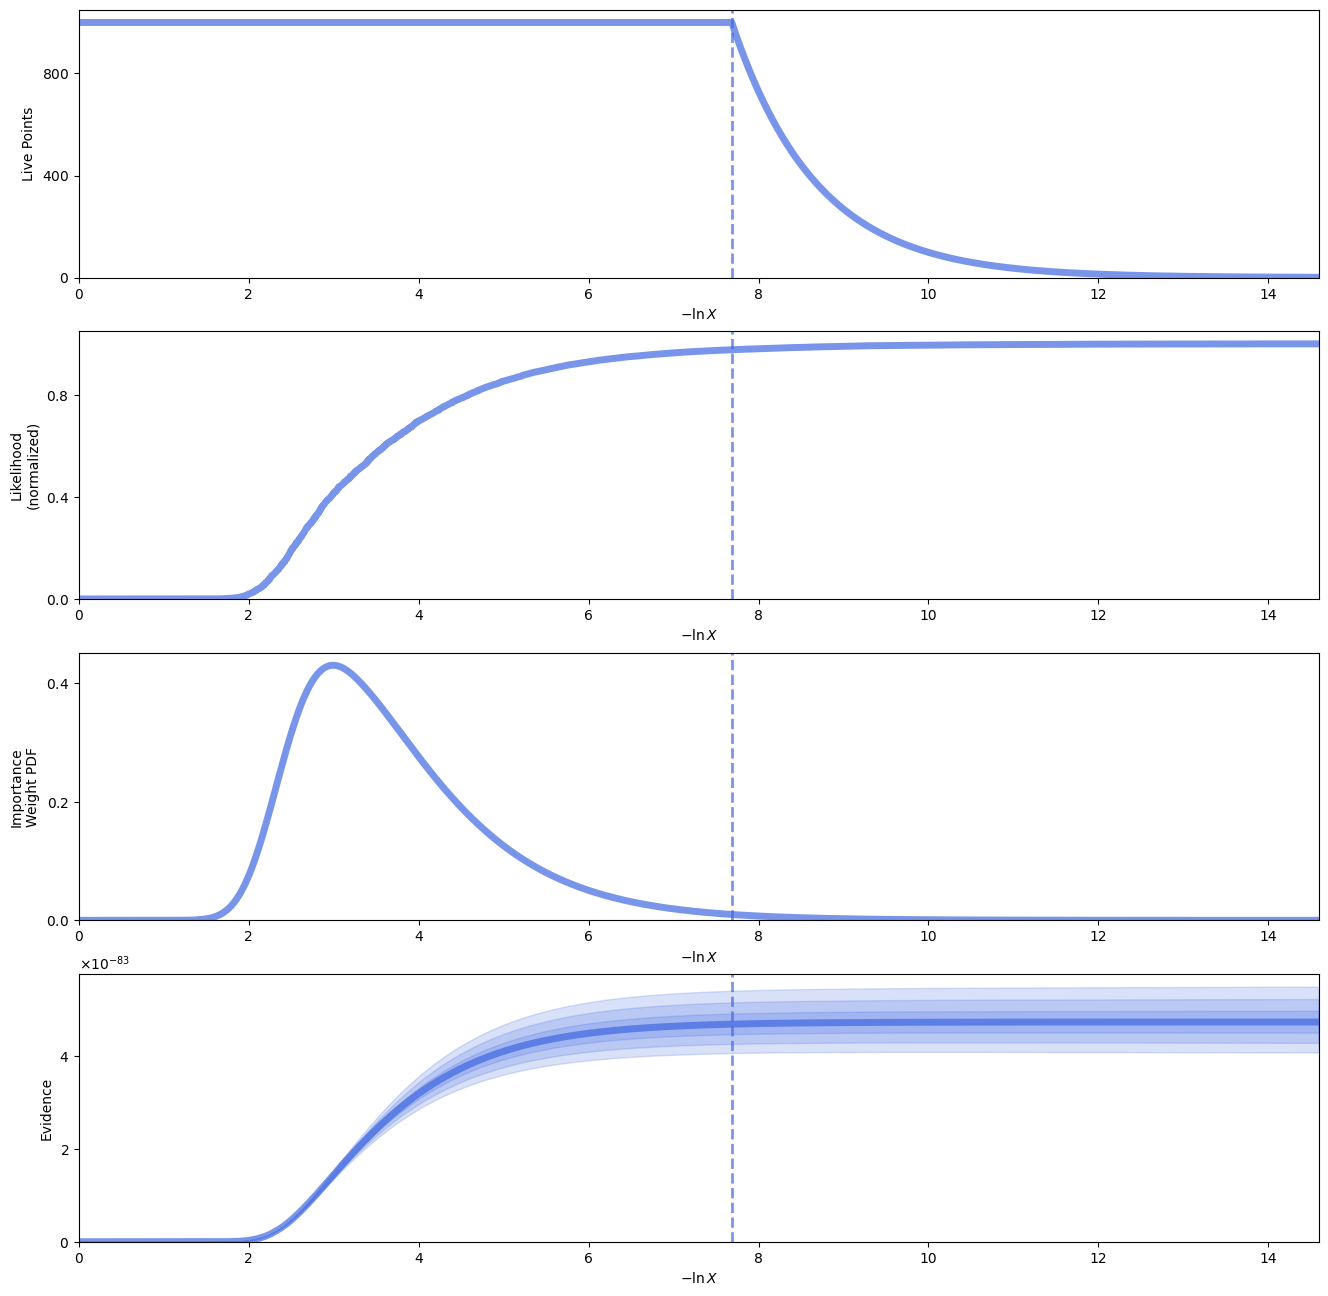

In [6]:
from dynesty import plotting as dyplot
rfig, raxes = dyplot.runplot(sresults, color='royalblue')

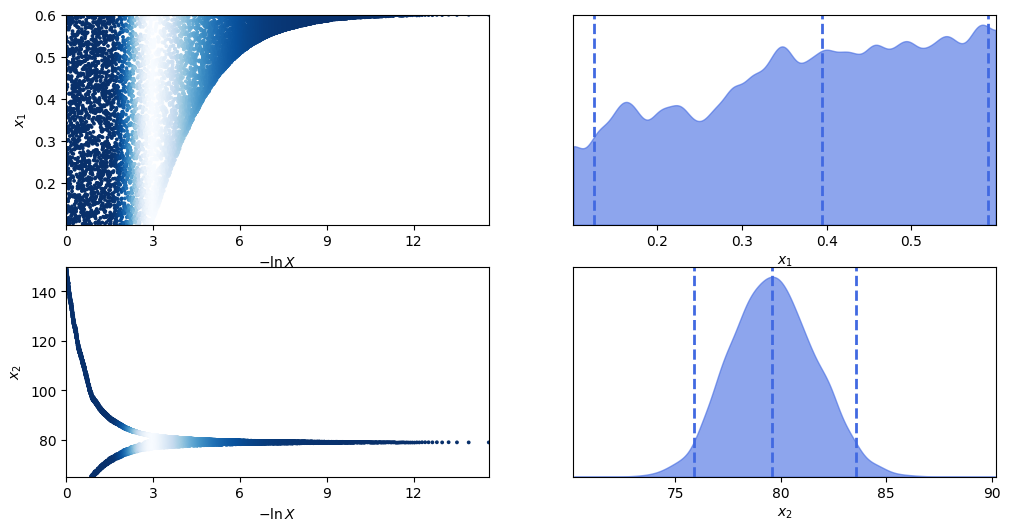

In [7]:
tfig, taxes = dyplot.traceplot(sresults, trace_cmap='Blues_r', post_color='royalblue')

from dynesty import utils as dyfunc
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

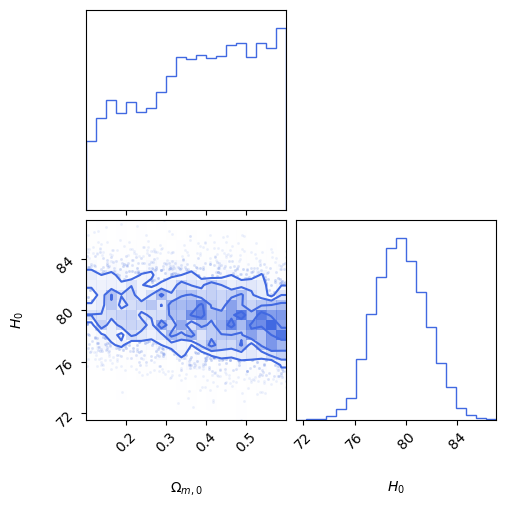

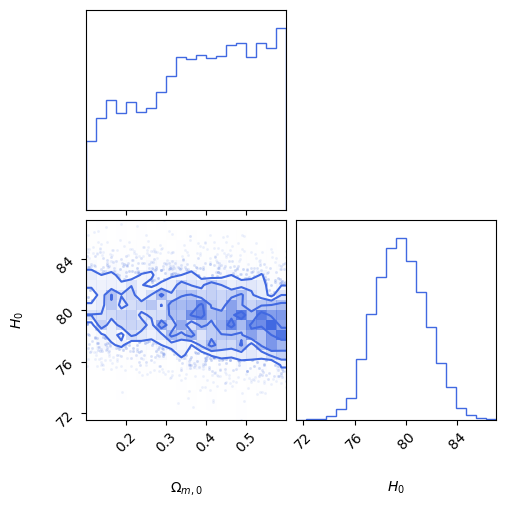

In [8]:
import corner
labels = [r"$\Omega_{m,0}$",r"$H_{0}$"]
samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal, labels=labels, color='royalblue')

Qualitatively speaking, I am expecting some level of anti-correlation between the two variables: in fact, I expect to get a faster expansion rate of the Universe if there is mode dark energy AND less matter.

I am also getting a significantly higher value for H0 and Omega0, with respect to what I am "expecting" to get from cosmology!

However, I also know that it was definetly hard to constrain the density parameters from these data alone (shaded blue areas in the image). 

![Image Description](https://lh4.googleusercontent.com/proxy/V5C07i4xEk7RQjaIjhZ3LLFsEOrbS-xkeQBj_9VkMr1QZwXu3LWfT1Dq6sf3vJUleyi06HJ9c0DidwqQprzhPf3Aq7PXJQxQAwFYbG6n9QQb)

I could probably check my dynesty setup, my prior definitions, and so on. So far, I am still getting results that are consistent with what the "better, true" values are.

- How would a model without dark energy (i.e. $\Omega_{m}=1$) perform? Do these data contain evidence of dark energy? (Hint: this is a model selection problem!)

In [9]:
zGrid = np.linspace(1e-6, 2, 1000)

from astropy.constants import c
c_kms = c.to(u.km/u.s).value

@njit(float64(float64, float64[:]))
def Model2(z, params):
    Om0 = 1
    H0  = params[1]
    Oe0 = 0
    zVals = np.linspace(0, z, 1000)
    integrand = np.sqrt(Om0*(1+zVals**3)+Oe0)**(-1)
    integral  = np.trapz(x=zVals, y=integrand)
    result = 5* np.log10(c_kms/H0*1e5 * (1+z) * integral) #1e5 = x Mpc / 10 pc
    if np.isnan(result) == True: return -np.inf
    return result

@njit(float64(float64[:]))
def LogLikelihood2(params):
    Om0, H0 = params    
    if Om0 < 0 : ### I really don't want negative masses
        return -np.inf
    logL = 0
    for z, mu, err in zip(zSample, muSample, dMu):
        logL = logL - ( mu - Model2(z, params) )**2 / 2*np.pi/err**2 - 0.5*np.log10(2*np.pi*err**2)
    if np.isnan(logL) == True: return -np.inf
    return logL

import scipy.stats
### Squeezing the domain around what I "know" to be the "correct" value. Sorry!
uGrid = np.linspace(0, 1, 10000)
ppf_Om0 = np.array( scipy.stats.uniform(0.1, 0.5).ppf(uGrid) )
ppf_H0  = np.array( scipy.stats.uniform(65 , 85 ).ppf(uGrid) ) 

@njit(float64[:](float64[:]))
def uPrior2(params):
    # Om0 = ppf_Om0[ ( np.abs(uGrid - params[0]) ).argmin() ]
    Om0 = 1
    H0  = ppf_H0 [ ( np.abs(uGrid - params[1]) ).argmin() ]
    return np.array([Om0, H0]) 

import dynesty
sampler2 = dynesty.NestedSampler(LogLikelihood2, uPrior2, ndim=2, nlive=1000)
sampler2.run_nested(print_progress=True, dlogz=0.01)
sresults2 = sampler2.results

7408it [00:32, 225.22it/s, +1000 | bound: 6 | nc: 1 | ncall: 44741 | eff(%): 19.222 | loglstar:   -inf < -186.383 <    inf | logz: -189.259 +/-  0.048 | dlogz:  0.000 >  0.010]


C:\Users\alfac\AppData\Local\Programs\Python\Python312\Lib\site-packages\dynesty\plotting.py:706: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min(x), max(x)])
C:\Users\alfac\AppData\Local\Programs\Python\Python312\Lib\site-packages\dynesty\plotting.py:749: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(span[i])


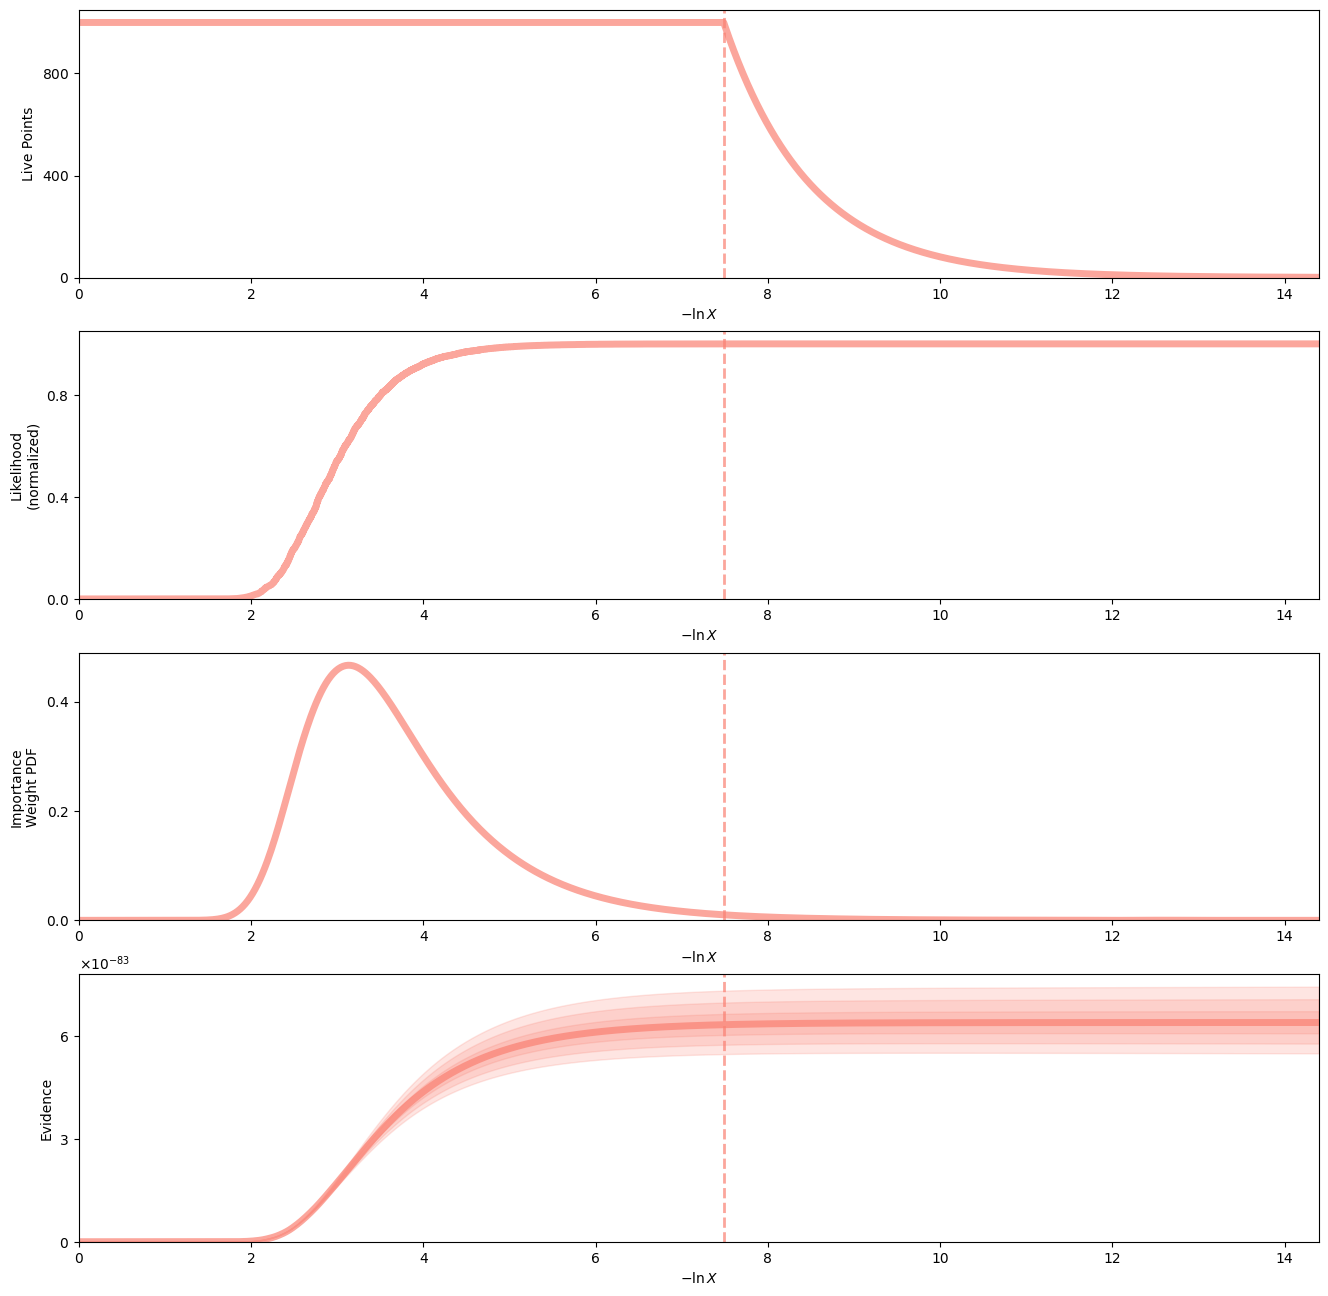

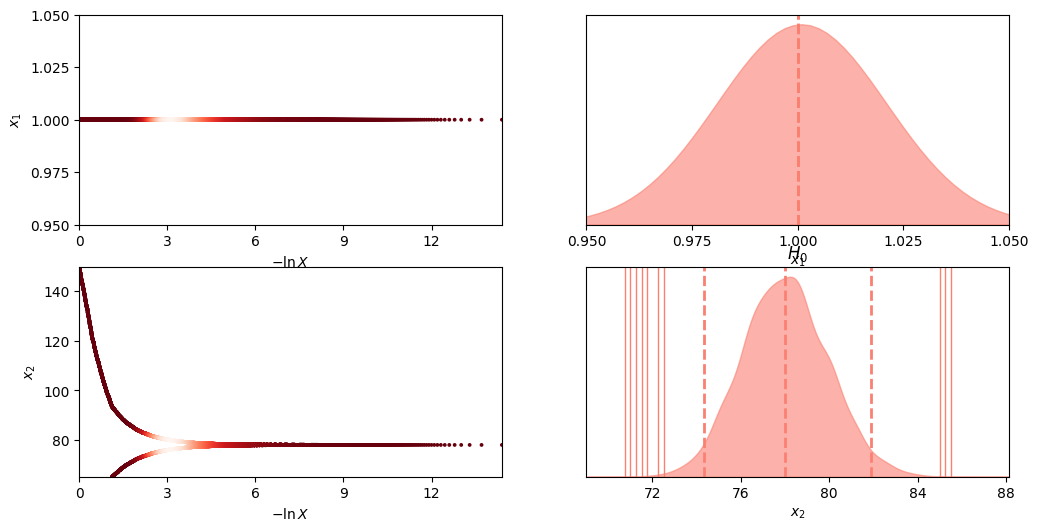

In [10]:
rfig2, raxes2 = dyplot.runplot(sresults2, color='salmon') 
tfig2, taxes2 = dyplot.traceplot(sresults2, trace_cmap='Reds_r', post_color='salmon')

from dynesty import utils as dyfunc
samples2 = sresults2.samples  # samples
weights2 = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights

samples_equal2 = dyfunc.resample_equal(samples2, weights2)
H0 = samples_equal2[:,1]
from astropy.visualization import hist
_ = hist(H0, bins='freedman', histtype='step', edgecolor='salmon')
_ = plt.title(labels[1])

Please, ignore the x1 dyplot. I just had to feed it to the algorithm.

In [11]:
np.exp(sampler2.results.logz[-1])/np.exp(sampler.results.logz[-1])

1.3537416631810915

This result is indeed inconclusive! Judging by the SNe data alone, I can't say much more than what I am currently showing.

- Think about the pdf of these data in $z$. Using both the GPR fit and your latest $\Lambda$CDM fit, generate a set of $\mu$ measurements that respects the statistical properties of the data you were given.

First step, let's pick a sample of z's which is respecting the z distribution at our disposal. I could do something like this:

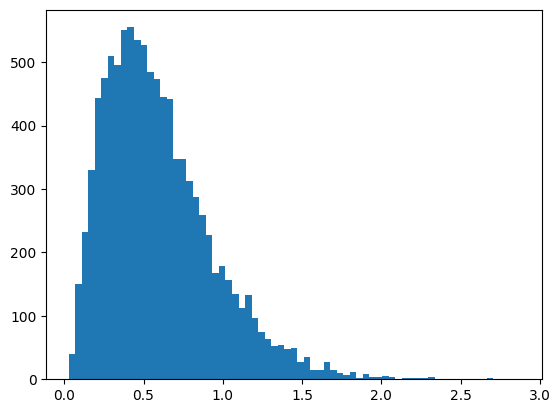

In [72]:
zSample, muSample, dMu = Load_Dataset(int(1e4))
_ = hist(zSample, bins='freedman')

But it feels like cheating a bit. Let's do something like this, in a similar fashion.

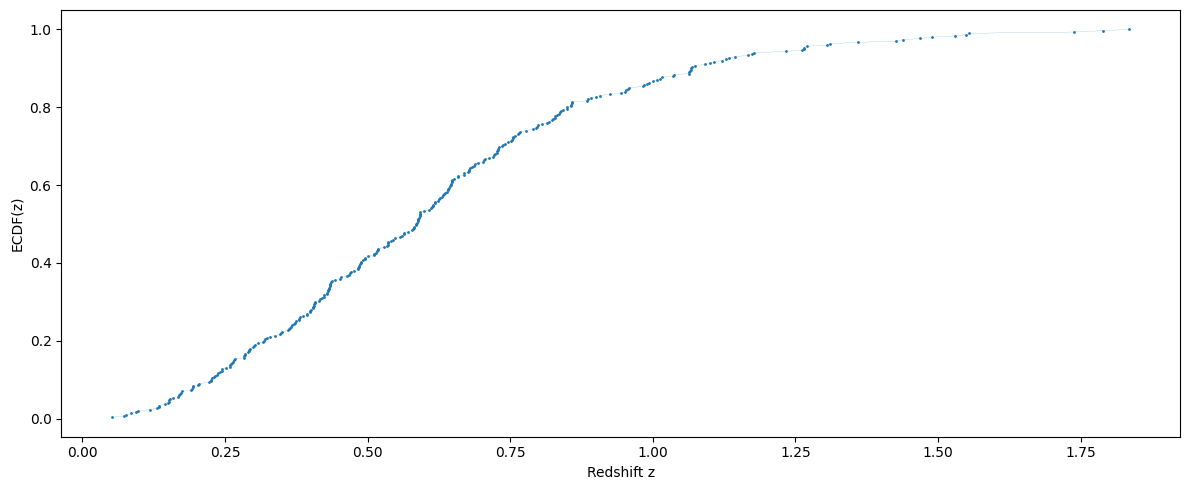

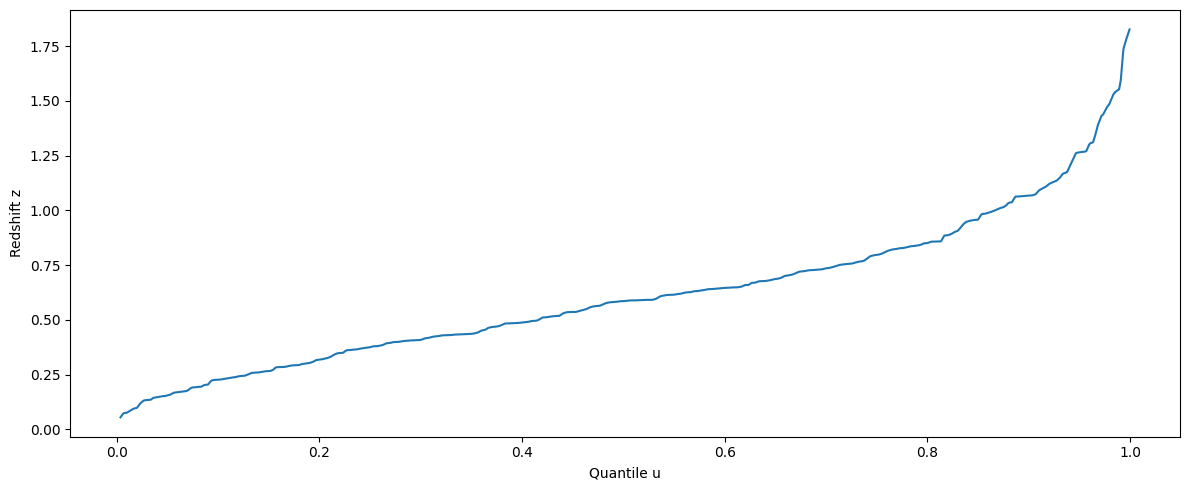

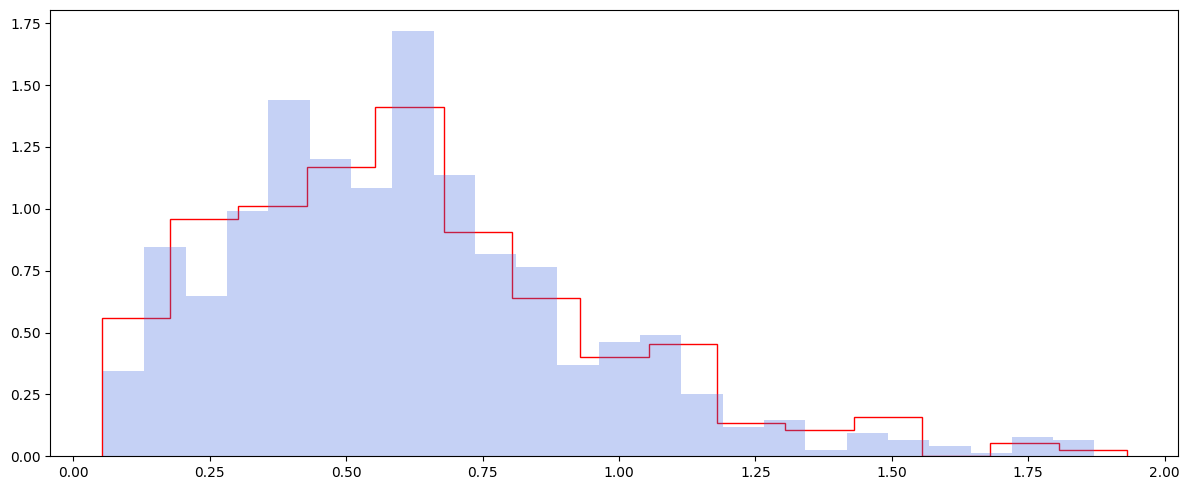

In [78]:
zSample, _, _ = Load_Dataset(300)
from scipy.stats import ecdf
zSample = np.sort(zSample)
cdf = ecdf(zSample).cdf
plt.figure(figsize=(12,5), tight_layout=True)
plt.plot(zSample, cdf.evaluate(zSample), marker='o', markersize=1, lw=0.1)
_ = plt.xlabel('Redshift z')
_ = plt.ylabel('ECDF(z)')

N = int(1e3)
U = np.random.uniform(min(cdf.evaluate(zSample)), max(cdf.evaluate(zSample)), size=N) ### I _really_ want to avoid being outside the interpolation range
from scipy.interpolate import interp1d
plt.figure(figsize=(12,5), tight_layout=True)
_ = plt.ylabel('Redshift z')
_ = plt.xlabel('Quantile u')
# This is naive but effective for my current purpose
inverse_ecdf = scipy.interpolate.interp1d(cdf.evaluate(zSample), zSample, fill_value='interpolate', kind='linear') 
_ = plt.plot(np.sort(U), inverse_ecdf(np.sort(U)))
zClones = inverse_ecdf(U)
plt.show()

from astropy.visualization import hist

plt.figure(figsize=(12,5), tight_layout=True)
_ = hist(zSample, bins='freedman', histtype='step', edgecolor='r', zorder=1, density=True)
_ = hist(zClones, bins='freedman', alpha=0.3, facecolor='royalblue', density=True)

The match is not perfect, but it works! Let's now produce some "real" SNe events.

1000it [00:00, 9967.93it/s]


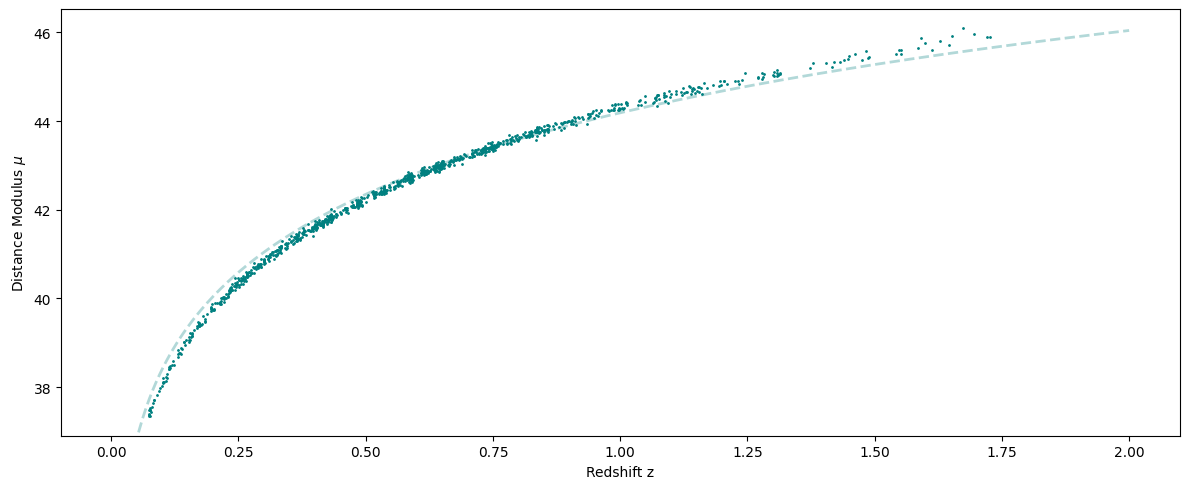

In [52]:
muClones = np.zeros(len(U))
from tqdm import tqdm
for i, z in tqdm(enumerate(zClones)):
    Om0 = np.random.choice(samples_equal[:,0])
    H0  = np.random.choice(samples_equal[:,1])
    muClones[i] = Model(z, np.array([Om0, H0]))

zGrid = np.linspace(1e-3, 2, 300)
plt.figure(figsize=(12,5), tight_layout=True)

plt.scatter(zClones, muClones, c='teal', s=1, label='Nested')
plt.ylim(plt.gca().get_ylim())
cosmo = FlatLambdaCDM(H0=100*0.673, Om0=0.3, Tcmb0=2.725)
plt.plot(zGrid, 5*np.log10(cosmo.luminosity_distance(zGrid).to(u.pc).value)-5, c='teal', lw=2, alpha=0.3, ls='--')
plt.xlabel("Redshift z")
_ = plt.ylabel(r"Distance Modulus $\mu$")

In [88]:
import warnings
warnings.filterwarnings("ignore") ### ruthless, but effective
muClones = np.zeros(len(U))
plt.figure(figsize=(12,5), tight_layout=True)

from tqdm import tqdm
for i, z in tqdm(enumerate(zClones)):
    mu, sigma   = GPR.predict([[z]], return_std=True)
    muClones[i] = np.random.normal(loc=mu, scale=sigma)
 
plt.scatter(zClones, muClones, c='rebeccapurple', s=1, label='GPR')    
plt.ylim(plt.gca().get_ylim())   
from astropy.cosmology import Planck18, FlatLambdaCDM
import astropy.units as u
cosmo = FlatLambdaCDM(H0=100*0.673, Om0=0.3, Tcmb0=2.725)
plt.plot(zGrid, 5*np.log10(cosmo.luminosity_distance(zGrid).to(u.pc).value)-5, c='rebeccapurple', lw=2, alpha=0.3, ls='--')
plt.xlabel("Redshift z")
_ = plt.ylabel(r"Distance Modulus $\mu$")

NameError: name 'U' is not defined

Conclusions: I have managed to upsample the distribution and provide some "new" data-driven datasets, however I have to conclude that the GPR algorithm is not doing great, at least by eye. The first solution I can think of to "fix" its performance is to cross-validate a few kernels and kernel parameters, yet I don't have the time to do this at the moment.

In [ ]:
# 1. Vanilla Linear Regression
# 2. GPR Fit con Kernel Constant + RBF // tweak the parameters! (not much, set constant tra 0.001 e 1000) // puoi fidarti ma dovresti fare cross-validation
# 3. Ti viene restituita uncertainty in your prediction
# 4. Non sempre pratico: EXPENSIVE TO RUN. Training a GPR is EXPENSIVE, evaluating a GPR is NOT CHEAP, as well. Neural Network: training EXPENSIVE, evaluating CHEAP.
# 5. Parametric Fit Bayesiano - MCMC e Nested Sampling application
# 6. Cornerplot Results: "True" value indicato 
# 7. Extract some models from the posterior, plot
# 8. GLI ULTIMI DUE PUNTI SEEM TO BE OFF - Prova a vedere che succede.
# 9. Anticorrelation tra H0 e Om -> prova a invertire un parametro e vedi se fitta meglio.
#10. Prova modello senza Dark Energy
#11. Generate Mock Data (cloning) - parto dal fit e vedo cosa esce. Key difference: orange is data driven. Blue is theory driven.
#12. WRONG orange: ho assunto redshift distr. che è UNIFORME in (0,2) - FALSO.
#13. Come si risolve quest'ultimo problema? UP TO YOU.